# News Rec-Sys Part 1

## Introduction
The background of news recommendation in news APP is **required us to predict the user's future click behavior based on the data information of the user's historical browsing and clicking on news articles, that is, the news article that the user clicked for the last time**.

## Data Overview
User interaction data, including 300,000 users, nearly 3 million clicks, and more than 360,000 different news articles. At the same time, each news article has a corresponding embedding vector representation.

From it, 200,000 users' click log data are extracted as the training set, 50,000 users' click log data are used as the test set A, and 50,000 users' click log data are used as the test set B.

# Data table

- train_click_log.csv: training set user click log
- testA_click_log.csv: test set user click log
- articles.csv: news article information data table
- articles_emb.csv: news article embedding vector representation

|        **Field**        |         **Description**          |
| :---------------------: | :------------------------------: |
| user_id | User id |
| click_article_id | Click article id |
| click_timestamp | Click timestamp |
| click_environment | Click environment |
| click_deviceGroup | Click device group |
| click_os | Click operating system |
| click_country | Click city |
| click_region | Click region |
| click_referrer_type | Click source type |
| article_id | Article id, corresponding to click_article_id |
| category_id | Article type id |
| created_at_ts | Article creation timestamp |
| words_count | Article word count |
| emb_1,emb_2,...,emb_249 | Article embedding vector representation |



## Evaluation indicators
The format we submit at the end is for each user. We will give the recommended results of five articles, sorted from the beginning to the end according to the click probability.

The article that each user clicked last will only have one real answer, so we will see whether there is a real answer among the five articles we recommend.

For example, for user1, our submission will be:
>user1, article1, article2, article3, article4, article5.

The formula of the evaluation is as follows:
$$
score(user) = \sum_{k=1}^5 \frac{s(user, k)}{k}
$$

If article1 is the article that the real user clicked, that is, article1 hits, then s(user1,1)=1, s(user1,2-4) are all 0. If article2 is the article that the user clicked, then s(user,2)=1/2, s(user,1,3,4,5) are all 0. In other words, score(user)=the inverse of the number of hits. If none of them hits, then score(user1)=0. This is reasonable, because what we want is to hit the result as early as possible, and the score happens to be relatively high at this time.

## Project Understanding
According to the project introduction, we must first clarify the goal of our project: predict the news article that the user clicked on last time based on the data information of the user's historical browsing and clicking on news. From this goal, we will find that this project is different from the ordinary structured projects we have encountered before, mainly in two points:

- First of all, in terms of the goal, we need to predict the news article that was clicked on last time, that is, we recommend news articles to users, not like the previous problem of predicting a number or predicting which type of data

- In terms of data, through the given data, we will find that this kind of data is not the kind of feature + label data we encountered before, but is based on real business scenarios, and the user's click log

So when we get this topic, our thinking direction is to combine our goals and **turn the prediction problem into a supervised learning problem (feature + label), and then we can perform ML, DL and other modeling predictions**.

Then we should naturally have the following questions in our mind:
- How to turn it into a supervised learning problem?
- What kind of supervised learning problem should it be turned into?
- What features can we use?
- What models can we try?
- What strategies do we have for recommending tens of thousands of articles this time?

Of course, these questions will not be answered immediately after we see the project, but as long as we have the problem, we can find a way to solve it. For example, what kind of supervised learning problem should it be turned into for the second question above?

Since we are predicting the news article that the user clicked on last, if we predict a certain article from 360,000 articles, we may first think that this may be a multi-classification problem (select 1 from 360,000 categories), but such a huge classification problem may be difficult for us to do, so can we convert it?

Since we want to predict the article that was clicked on last, if we can predict the probability that a user will click on a certain article for the last time, does it indirectly solve this problem? Isn't the article with the highest probability the news article that the user may click on last time? This turns the original problem into a click-through rate prediction problem (user, article) --> click probability (soft classification), and this problem is the classification problem in the supervised learning field that we are familiar with. In this way, when we build models later, we basically have a general direction for the choice of model, such as the simplest logistic regression model.

In this way, we should have a general solution to the solution of this project. We should first turn it into a classification problem. The classification label is whether the user will click on a certain article. The characteristics of the classification problem will include users and articles. We need to train a classification model to predict the probability of a user clicking on a certain article for the last time. Then there will be several questions: How to turn it into a supervised learning problem? How to make training sets and test sets? What features can we use? What models can we try? Faced with 360,000 articles and recommendations from more than 200,000 users, what strategies do we have to reduce the scale of the problem? How to make the final prediction?
## Data preprocessing & data analysis

**Step 1: User attribute analysis**

- **User quantity distribution**: Analyze the number of users in the training set and the test set through visualization charts to understand the overall scale of user data.

- **User city distribution pattern**: Analyze the geographical distribution of users through city dimension data visualization to explore whether there are regional concentration or dispersion characteristics.

- **User average clicks**: Calculate the average article clicks for each user and display them through charts to understand the user activity distribution.

- **Correlation between click sources and article clicks**: Analyze the relationship between different click sources (such as home page recommendations, search results, etc.) and article clicks to determine whether there are differences in user behavior patterns from different sources.

**Step 2: User behavior analysis**

- **Time pattern of user click behavior**: Analyze the user's continuous click behavior through visualization of timestamp data to determine whether the user's reading habits or continuous click patterns can be identified from the click interval.

- **Similarity between articles**: Analyze whether there is content similarity when users read different articles, use the user's click sequence to perform article similarity analysis, and visualize it.
- **Correlation between click sources and article types**: Analyze the correlation between the source (such as recommendation, search, etc.) when users click on articles and the article type (such as news, entertainment, technology, etc.), and explore whether there are differences in user preferences under different sources.

**Step 3: Article content analysis**

- **Correlation between article word count and click count**: By analyzing the relationship between article word count and click count, determine whether article length has an impact on click volume, and display the correlation through charts.
- **Clustering and dimensionality reduction visualization of article embedding vectors**: Use article embedding vectors to calculate similarity, try to cluster articles, and visualize the clustering results through dimensionality reduction techniques (such as PCA or t-SNE) to intuitively display the content similarity between articles.
- **Correlation between article creation time and click time**: Through data analysis of article creation time and user click time, determine whether articles in a specific time period are more likely to be clicked, and visualize the relationship between time interval and click behavior.




## Import Package

In [29]:
# %matplotlib inline # Display the plot results in Jupyter Notebook

import pandas as pd # Import the pandas library for data processing and analysis
import numpy as np # Import the NumPy library for numerical calculations

import matplotlib.pyplot as plt # Import the matplotlib library for data visualization
import seaborn as sns # Import the seaborn library for more beautiful data visualization
plt.rc('font', family='SimHei', size=13) # Set the font to SimHei (Chinese bold), font size to 13

import os # Import the os module for operating system related functions
import gc # Import the gc module for garbage collection
import re # Import the re module for regular expression operations
import warnings # Import the warnings module for ignoring warning messages
import sys # Import the sys module for accessing system related functions

warnings.filterwarnings("ignore") # Ignore warning messages

## Reading Data

In [30]:
from google.colab import drive

# Connect to Google Drive (transfer data to your own Google Drive)
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [31]:
data_path = '/content/drive/My Drive/项目/推荐系统/data/data_raw/' # Data path, used to specify the storage location of the original data
save_path = '/content/drive/My Drive/项目/推荐系统/data/temp_results/' # Storage path, used to specify the storage location of temporary results


#####train
trn_click = pd.read_csv(data_path+'train_click_log.csv')
item_df = pd.read_csv(data_path+'articles.csv')
item_df = item_df.rename(columns={'article_id': 'click_article_id'})  #Rename to facilitate subsequent matching
item_emb_df = pd.read_csv(data_path+'articles_emb.csv')

#####test
tst_click = pd.read_csv(data_path+'testA_click_log.csv')

## Data preprocessing
Calculate user click rank and click count

In [32]:
trn_click.head()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type
0,199999,160417,1507029570190,4,1,17,1,13,1
1,199999,5408,1507029571478,4,1,17,1,13,1
2,199999,50823,1507029601478,4,1,17,1,13,1
3,199998,157770,1507029532200,4,1,17,1,25,5
4,199998,96613,1507029671831,4,1,17,1,25,5


In [33]:
# Sort the click timestamps for each user
trn_click['rank'] = trn_click.groupby(['user_id'])['click_timestamp'].rank(ascending=False).astype(int)
tst_click['rank'] = tst_click.groupby(['user_id'])['click_timestamp'].rank(ascending=False).astype(int)

In [34]:
trn_click[trn_click['user_id'] == 199999]

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank
0,199999,160417,1507029570190,4,1,17,1,13,1,11
1,199999,5408,1507029571478,4,1,17,1,13,1,10
2,199999,50823,1507029601478,4,1,17,1,13,1,9
211041,199999,123909,1507226987864,4,1,17,1,13,1,8
211042,199999,168623,1507227017864,4,1,17,1,13,1,7
660731,199999,161191,1507665351186,4,1,17,1,13,1,6
660732,199999,42223,1507665381186,4,1,17,1,13,1,5
709171,199999,70214,1507721405411,4,1,17,1,13,1,4
709172,199999,156843,1507721435411,4,1,17,1,13,1,3
1081894,199999,159019,1508176837088,4,1,17,1,13,1,2


In [35]:
#Count the number of times a user clicks on an article and add a new column count
trn_click['click_cnts'] = trn_click.groupby(['user_id'])['click_timestamp'].transform('count')
tst_click['click_cnts'] = tst_click.groupby(['user_id'])['click_timestamp'].transform('count')

## Data browsing

### User click log file_training set

In [36]:
trn_click = trn_click.merge(item_df, how='left', on=['click_article_id'])
trn_click.head()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count
0,199999,160417,1507029570190,4,1,17,1,13,1,11,11,281,1506942089000,173
1,199999,5408,1507029571478,4,1,17,1,13,1,10,11,4,1506994257000,118
2,199999,50823,1507029601478,4,1,17,1,13,1,9,11,99,1507013614000,213
3,199998,157770,1507029532200,4,1,17,1,25,5,40,40,281,1506983935000,201
4,199998,96613,1507029671831,4,1,17,1,25,5,39,40,209,1506938444000,185


#### The meaning of each field in the train_click_log.csv file data

1. user_id: user's unique ID
2. click_article_id: unique ID of the article clicked by the user
3. click_timestamp: timestamp when the user clicks the article
4. click_environment: environment in which the user clicks the article
5. click_deviceGroup: device group when the user clicks the article
6. click_os: operating system when the user clicks the article
7. click_country: country where the user is when clicking the article
8. click_region: region where the user is when clicking the article
9. click_referrer_type: source of the article when the user clicks the article

In [37]:
#User click log information
trn_click.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1112623 entries, 0 to 1112622
Data columns (total 14 columns):
 #   Column               Non-Null Count    Dtype
---  ------               --------------    -----
 0   user_id              1112623 non-null  int64
 1   click_article_id     1112623 non-null  int64
 2   click_timestamp      1112623 non-null  int64
 3   click_environment    1112623 non-null  int64
 4   click_deviceGroup    1112623 non-null  int64
 5   click_os             1112623 non-null  int64
 6   click_country        1112623 non-null  int64
 7   click_region         1112623 non-null  int64
 8   click_referrer_type  1112623 non-null  int64
 9   rank                 1112623 non-null  int64
 10  click_cnts           1112623 non-null  int64
 11  category_id          1112623 non-null  int64
 12  created_at_ts        1112623 non-null  int64
 13  words_count          1112623 non-null  int64
dtypes: int64(14)
memory usage: 118.8 MB


In [38]:
#The number of users in the training set is 20w
trn_click.user_id.nunique()

200000

In [39]:
trn_click.groupby('user_id')['click_article_id'].count().min()  # Each user in the training set clicked on at least two articles

2

##### Draw a histogram to roughly look at the basic attribute distribution

In [40]:
# Change the Font to Chinese because there is Chinese Font in matplotlib

!wget -q -O TaipeiSansTCBeta-Regular.ttf https://drive.google.com/uc?id=1eGAsTN1HBpJAkeVM57_C7ccp7hbgSz3_&export=download

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.font_manager import fontManager

fontManager.addfont('TaipeiSansTCBeta-Regular.ttf')
mpl.rc('font', family='Taipei Sans TC Beta')

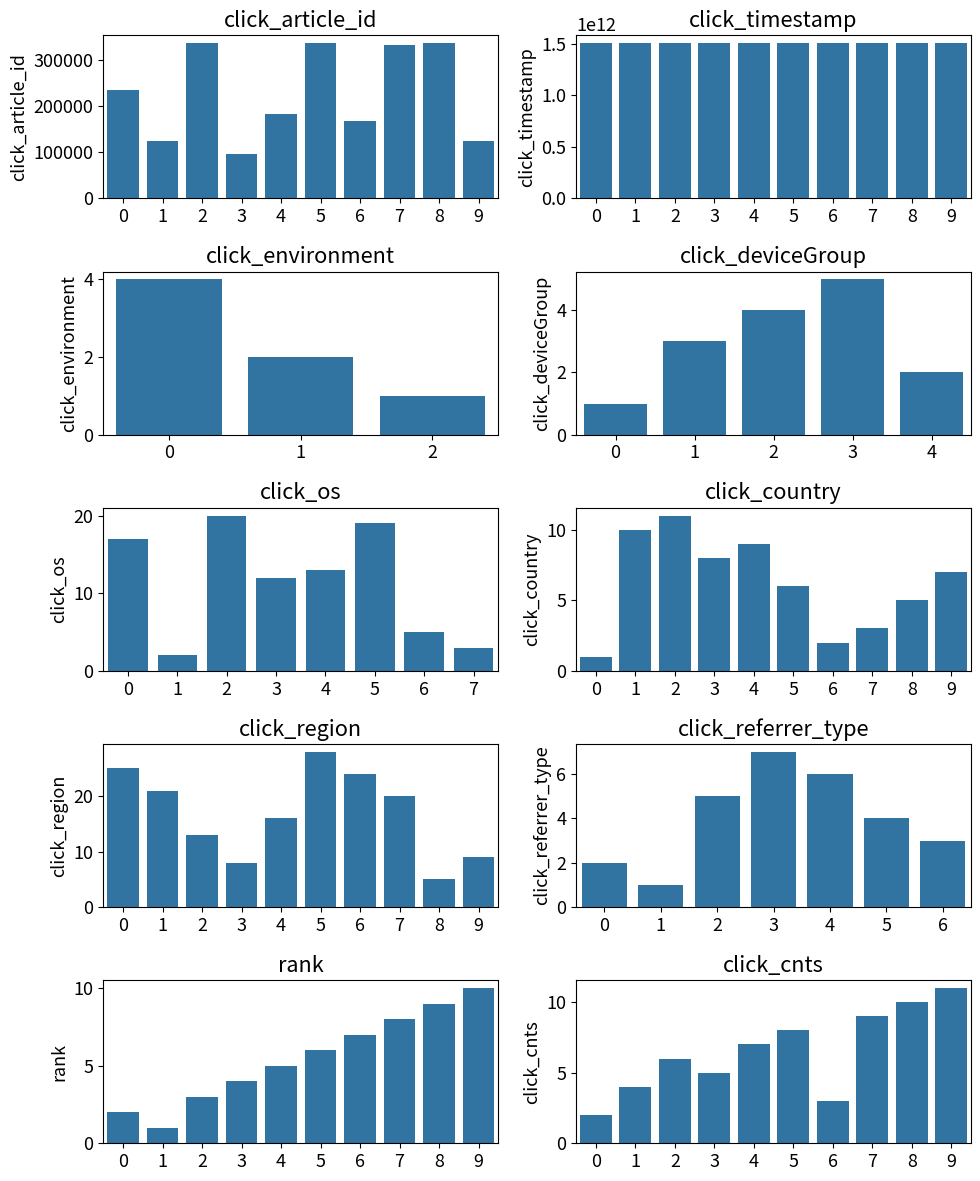

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_bar_chart(data, column, ax):
    """
    Draw a bar chart
    """
    value_counts = data[column].value_counts().reset_index()[:10]
    sns.barplot(x=value_counts.index, y=value_counts[column], ax=ax)
    for item in ax.get_xticklabels():
        item.set_rotation(0)
    ax.set_title(column)
    ax.set_xlabel('')

# Create a new graphics window
fig, axes = plt.subplots(5, 2, figsize=(10, 12))

# Place the sub-images in a 5x2 grid
for i, column in enumerate(['click_article_id', 'click_timestamp', 'click_environment', 'click_deviceGroup',
                            'click_os', 'click_country', 'click_region', 'click_referrer_type', 'rank', 'click_cnts']):
    plot_bar_chart(trn_click, column, axes[i//2, i%2])

plt.tight_layout()
plt.show()


In [42]:
trn_click['click_deviceGroup'].value_counts(normalize = True)

,proportion
click_deviceGroup,
1,0.609539
3,0.355518
4,0.034811
5,0.000127
2,0.000005


From the click device group click_deviceGroup, device 1 accounts for the majority (61%), and device 3 accounts for 36%.

### Test set user click log

In [43]:
tst_click = tst_click.merge(item_df, how='left', on=['click_article_id'])
tst_click.head()

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count
0,249999,160974,1506959142820,4,1,17,1,13,2,19,19,281,1506912747000,259
1,249999,160417,1506959172820,4,1,17,1,13,2,18,19,281,1506942089000,173
2,249998,160974,1506959056066,4,1,12,1,13,2,5,5,281,1506912747000,259
3,249998,202557,1506959086066,4,1,12,1,13,2,4,5,327,1506938401000,219
4,249997,183665,1506959088613,4,1,17,1,15,5,7,7,301,1500895686000,256


In [44]:
set(trn_click.user_id) & set(tst_click.user_id)

set()

The users in the training set and the test set are completely different (no intersection)

The user IDs of the training set range from 0 to 199999, while the user IDs of the test set A range from 200000 to 249999.

Therefore, when we train, we need to include the data of the test set, which is called full data.

In [45]:
#The number of users in the test set is 5w
tst_click.user_id.nunique()

50000

In [46]:
tst_click.groupby('user_id')['click_article_id'].count().min() # Note that there are users in the test set who have only clicked on the article once

1

### News article information data table


In [47]:
#News Article Dataset Browsing
pd.concat([item_df.head(),item_df.tail()])

,click_article_id,category_id,created_at_ts,words_count
0,0,0,1513144419000,168
1,1,1,1405341936000,189
2,2,1,1408667706000,250
3,3,1,1408468313000,230
4,4,1,1407071171000,162
364042,364042,460,1434034118000,144
364043,364043,460,1434148472000,463
364044,364044,460,1457974279000,177
364045,364045,460,1515964737000,126
364046,364046,460,1505811330000,479


#### Article word count

1. Overall distribution of article word count

See whether there are more short articles or long articles. See if there are some extreme values ​​or concentrated word count intervals. If short articles are the majority, it may mean that content consumption on the platform tends to be quick browsing. If there are more long articles, users may have a certain demand for in-depth reading.



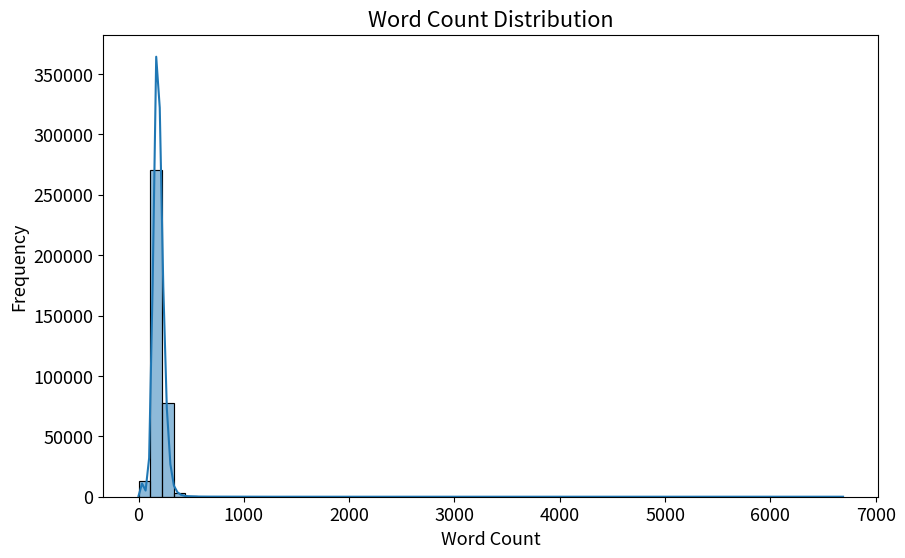

In [48]:
# Draw a histogram of word count distribution
plt.figure(figsize=(10, 6))
sns.histplot(item_df['words_count'], bins=60, kde=True)
plt.title('Word Count Distribution')
plt.xlabel('Word Count')
plt.ylabel('Frequency')
plt.show()

<Axes: >

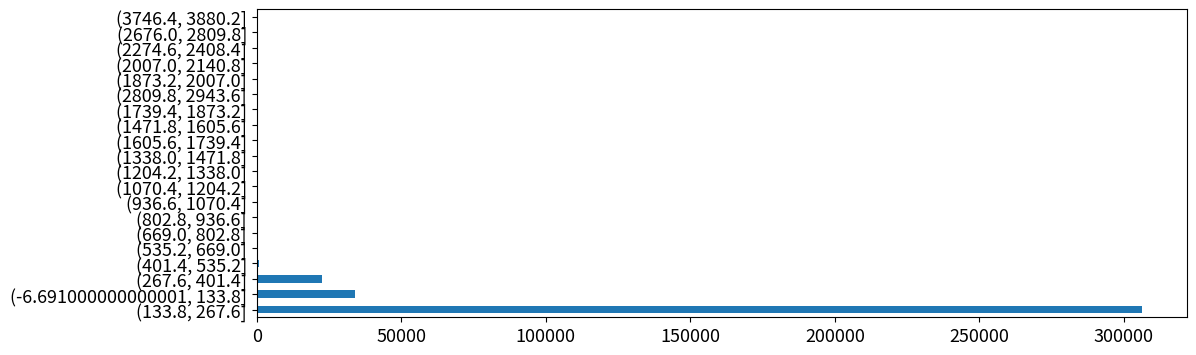

In [49]:
# You can also use value_counts to bin
item_df['words_count'].value_counts(bins = 50)[:20].plot(kind = 'barh',rot = 0, figsize = [12,4])

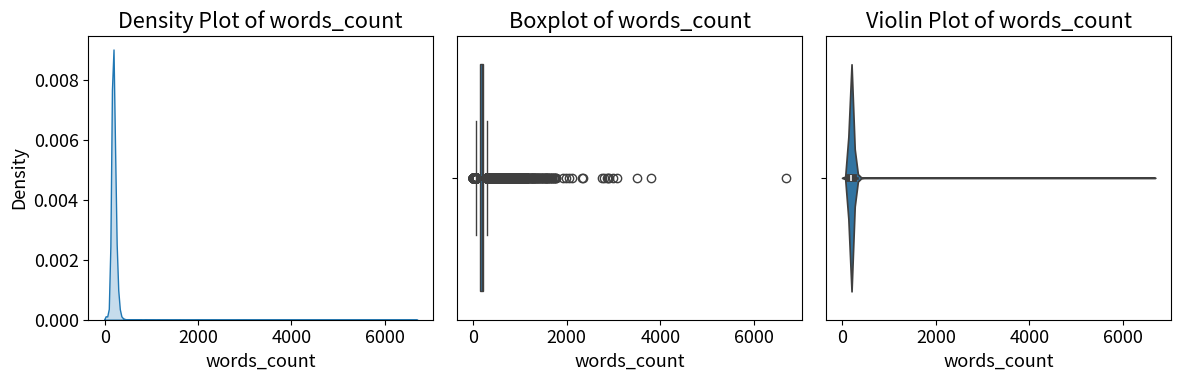

In [50]:
# You can also use more complex charts

def plot_distribution(data, column):
    """
  Draw three types of charts for data distribution: KDE, Boxplot and Violin Plot

  Parameters:
  - data: DataFrame, containing the data to be drawn
  - column: str, the name of the column to be drawn
  """
    plt.figure(figsize=(12, 4))

    # KDE
    plt.subplot(1, 3, 1)
    sns.kdeplot(data[column], shade=True)
    plt.xlabel(column)
    plt.ylabel('Density')
    plt.title('Density Plot of ' + column)

    # Box plot
    plt.subplot(1, 3, 2)
    sns.boxplot(x=data[column])
    plt.xlabel(column)
    plt.title('Boxplot of ' + column)

    # Violin Plot
    plt.subplot(1, 3, 3)
    sns.violinplot(x=data[column])
    plt.xlabel(column)
    plt.title('Violin Plot of ' + column)

    plt.tight_layout()
    plt.show()

plot_distribution(item_df, 'words_count')

2. Relationship between word count and publishing time

Is there a trend in the number of words in articles published in different time periods? If the number of words changes over time, it may indicate that the platform content strategy has changed, or that users' preferences for long and short articles are changing.

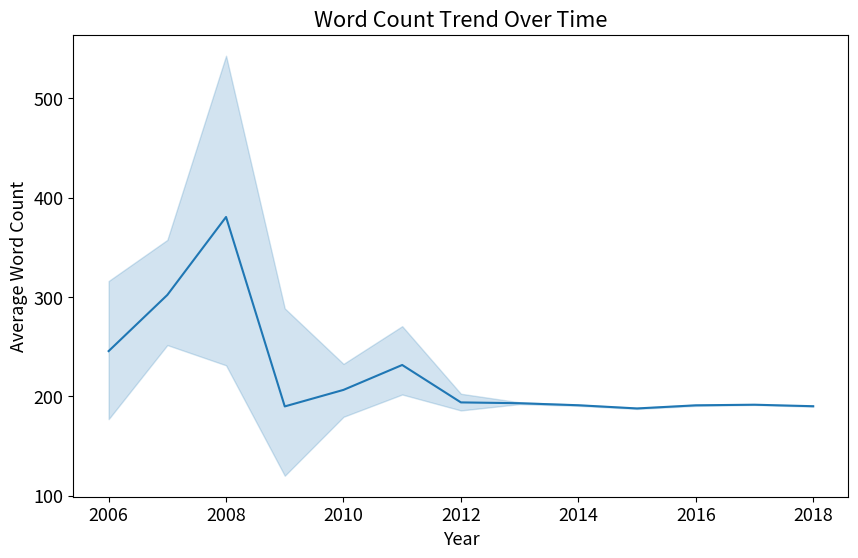

In [23]:
# Convert timestamp to date format
item_df['created_at'] = pd.to_datetime(item_df['created_at_ts'], unit='ms')

# Analyze word count trends by year
item_df['year'] = item_df['created_at'].dt.year
plt.figure(figsize=(10, 6))
sns.lineplot(x='year', y='words_count', data=item_df)
plt.title('Word Count Trend Over Time')
plt.xlabel('Year')
plt.ylabel('Average Word Count')
plt.show()

3. Relationship between word count and article type (category_id)

Intuitively see the word count distribution of articles in different categories and understand whether the word count of certain types of articles is more concentrated or more dispersed.

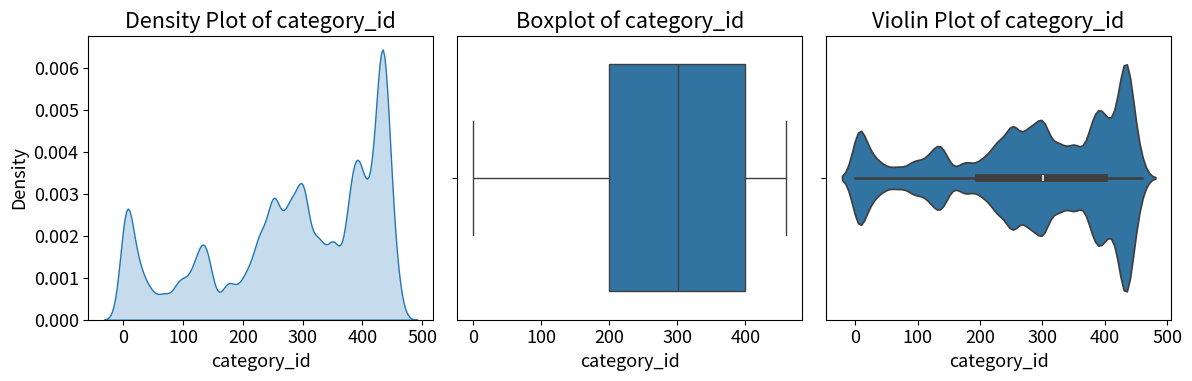

In [26]:
# Group by category and draw a box plot to view the word count distribution
plot_distribution(item_df, 'category_id')

### News article embedding vector representation

The embedding vector representation of news articles refers to representing each news article as a fixed-length vector, which is usually obtained by mapping words or other semantic units in the article to real vectors in a high-dimensional space. The purpose of this representation method is to encode the semantic information of the article into a vector form.

Suppose we have the following two news articles:

Article A: "Scientists have discovered that a new vaccine can effectively prevent influenza"

Article B: "National policies have been introduced to encourage companies to increase environmental protection investment"

We can use a pre-trained word embedding model (such as Word2Vec, GloVe, or FastText) to map each word to a fixed-length vector. Suppose our word embedding model is a 100-dimensional vector.

Then, we can calculate the embedding vector for each article. There are usually several ways to do this:

Average vector: average the vectors of each word in the article to get the embedding vector of the entire article.

Weighted average vector: weighted average the vectors of each word in the article, and the weight can be TF-IDF value, etc.
Model encoding: Use a deep learning model (such as recurrent neural network, Transformer, etc.) to encode the entire article and obtain a fixed-length vector of the article.
Assuming that we use the average vector method, the word vector in article A is as follows (assuming that the vector dimension is 3 for simplicity):

- "scientists": [0.2, 0.1, 0.5]
- "discovery": [0.3, 0.2, 0.4]
- "new": [0.1, 0.4, 0.3]
- "vaccine": [0.5, 0.6, 0.2]
... (vectors of other words)

The embedding vector of article A can be obtained by averaging these word vectors


In [51]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [53]:
import nltk
import numpy as np

# Download the data required by NLTK
nltk.download('punkt')

# Article Content
article = "This week’s White House Report Card capped an eventful week that showed inflation was still hot, a major pollster predicting President Joe Biden’s reelection defeat, and Russian President Vladimir Putin offering an unwelcome election endorsement."

# word token
tokens = nltk.word_tokenize(article)

# Build a simple word embedding dictionary (randomly generate vectors)
embedding_dim = 100  # Assume that the word embedding vector dimension is 100
word_embeddings = {}
for word in set(tokens):
    word_embeddings[word] = np.random.rand(embedding_dim)

# Get the embedding vector of each word
word_vectors = [word_embeddings[word] for word in tokens if word in word_embeddings]

# Calculate the embedding vector of the entire article (take the average)
article_embedding = sum(word_vectors) / len(word_vectors)

print("The embedding vector of the article：", article_embedding)





The embedding vector of the article： [0.49200236 0.57986389 0.47784043 0.46293714 0.56031842 0.48024877
 0.47926213 0.49944564 0.58633863 0.50719189 0.43030564 0.49293663
 0.51135341 0.46035386 0.46887602 0.54158543 0.48472227 0.44133412
 0.52007996 0.37594013 0.48839537 0.47240532 0.54672664 0.57698933
 0.51233323 0.53984805 0.54246915 0.40907325 0.50352092 0.50710354
 0.61368853 0.50622263 0.56730326 0.55044234 0.52135738 0.45816738
 0.57788589 0.44813419 0.50044361 0.58690899 0.45561818 0.44896077
 0.48548206 0.56182409 0.54286883 0.38944821 0.52345684 0.5769766
 0.50568697 0.50910936 0.41901506 0.55830833 0.55481905 0.49848178
 0.53492065 0.47013112 0.49428822 0.46761487 0.53042513 0.44728791
 0.45203965 0.44023179 0.52459109 0.43059014 0.48953722 0.45952994
 0.43860229 0.39247868 0.51517384 0.49576458 0.51987262 0.44319348
 0.54682393 0.50753125 0.45727864 0.49766419 0.55970946 0.47528389
 0.45056568 0.52877041 0.3975301  0.4636962  0.52239626 0.54826244
 0.58215796 0.57388008 0.4

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


In [54]:
item_emb_df.head()

,article_id,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_240,emb_241,emb_242,emb_243,emb_244,emb_245,emb_246,emb_247,emb_248,emb_249
0,0,-0.161183,-0.957233,-0.137944,0.050855,0.830055,0.901365,-0.335148,-0.559561,-0.500603,...,0.321248,0.313999,0.636412,0.169179,0.540524,-0.813182,0.286870,-0.231686,0.597416,0.409623
1,1,-0.523216,-0.974058,0.738608,0.155234,0.626294,0.485297,-0.715657,-0.897996,-0.359747,...,-0.487843,0.823124,0.412688,-0.338654,0.320786,0.588643,-0.594137,0.182828,0.397090,-0.834364
2,2,-0.619619,-0.972960,-0.207360,-0.128861,0.044748,-0.387535,-0.730477,-0.066126,-0.754899,...,0.454756,0.473184,0.377866,-0.863887,-0.383365,0.137721,-0.810877,-0.447580,0.805932,-0.285284
3,3,-0.740843,-0.975749,0.391698,0.641738,-0.268645,0.191745,-0.825593,-0.710591,-0.040099,...,0.271535,0.036040,0.480029,-0.763173,0.022627,0.565165,-0.910286,-0.537838,0.243541,-0.885329
4,4,-0.279052,-0.972315,0.685374,0.113056,0.238315,0.271913,-0.568816,0.341194,-0.600554,...,0.238286,0.809268,0.427521,-0.615932,-0.503697,0.614450,-0.917760,-0.424061,0.185484,-0.580292


In [55]:
item_emb_df.shape

(364047, 251)

## Data Analysis

### User clicks repeatedly

In [56]:
#####merge
user_click_merge = pd.concat([trn_click,tst_click])

In [57]:
#User clicks repeatedly
user_click_count = user_click_merge.groupby(['user_id', 'click_article_id'])['click_timestamp'].agg({'count'}).reset_index()
user_click_count[:10]

,user_id,click_article_id,count
0,0,30760,1
1,0,157507,1
2,1,63746,1
3,1,289197,1
4,2,36162,1
5,2,168401,1
6,3,36162,1
7,3,50644,1
8,4,39894,1
9,4,42567,1


In [58]:
user_click_count[user_click_count['count']>7]

,user_id,click_article_id,count
311242,86295,74254,10
311243,86295,76268,10
393761,103237,205948,10
393763,103237,235689,10
576902,134850,69463,13


In [59]:
#Number of times users click on news
user_click_count.loc[:,'count'].value_counts()

,count
count,
1,1605541
2,11621
3,422
4,77
5,26
6,12
10,4
7,3
13,1


It can be seen that 1,605,541 (about 99.2%) users have not read the article repeatedly, and only a very small number of users have clicked on an article repeatedly. This can also be made into a feature separately

### Distribution of the number of news clicks by users

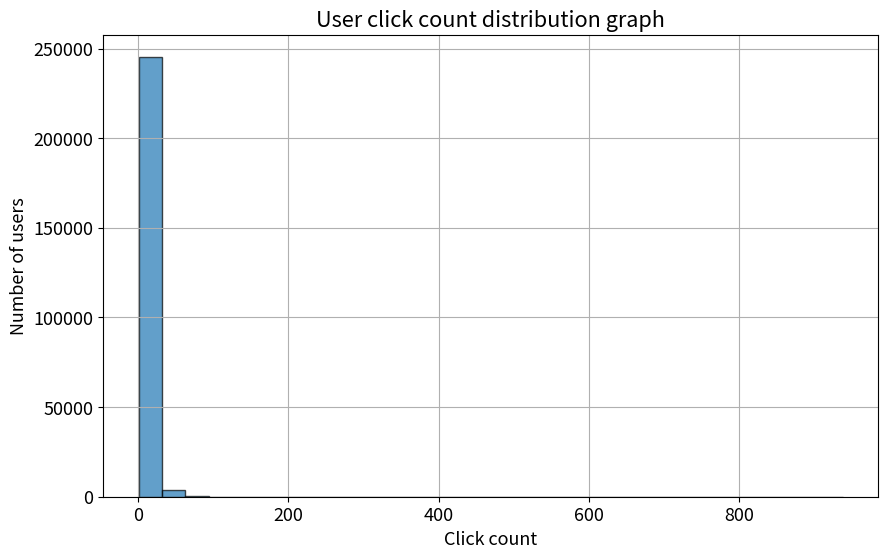

In [60]:
# Generate cumulative click count distribution
user_click_item_count = sorted(user_click_merge.groupby('user_id')['click_article_id'].count(), reverse=True)

# Draw a cumulative distribution graph
plt.figure(figsize=(10, 6))
plt.hist(user_click_item_count, bins=30, edgecolor='black', alpha=0.7)
plt.title('User click count distribution graph')
plt.xlabel('Click count')
plt.ylabel('Number of users')
plt.grid(True)
plt.show()

The user's activity can be seen by the number of times the user clicks on the article

9.0
2.0


Text(0, 0.5, 'Number of users')

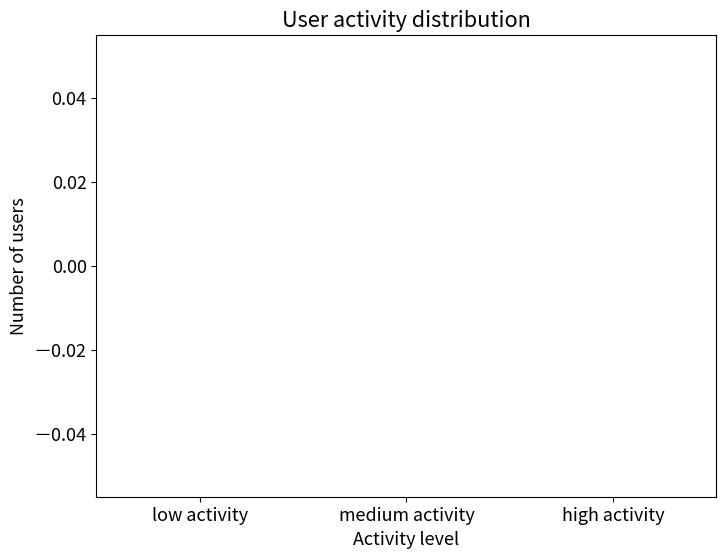

In [61]:
user_click_item_count_series = pd.Series(user_click_item_count)

threshold_high = user_click_item_count_series.quantile(0.8)
print(threshold_high)
threshold_low = user_click_item_count_series.quantile(0.2)
print(threshold_low)

user_activity_level = pd.cut(user_click_item_count_series, bins=[0, threshold_low, threshold_high, float('inf')], labels=['低活跃', '中活跃', '高活跃'])


activity_df = pd.DataFrame({'activity': user_activity_level})

# Draw a bar chart of activity distribution
plt.figure(figsize=(8, 6))
sns.countplot(data=activity_df, x='activity', palette='Set2', order=['low activity', 'medium activity', 'high activity'])

# Add title and label
plt.title('User activity distribution')
plt.xlabel('Activity level')
plt.ylabel('Number of users')

In [62]:
all(clicks > 100 for clicks in user_click_item_count[:50])

True

The top 50 users with the most clicks all have more than 100 clicks. Idea: We can define users with more than or equal to 100 clicks as active users. This is a simple processing idea. To judge user activity, a more comprehensive approach is to combine the click time. Later, we will judge user activity based on the number of clicks and click time.

In [63]:
print(f"The number of users whose click times are less than or equal to two is: {(user_click_item_count_series <= 2).sum()}")

The number of users whose click times are less than or equal to two is: 93464


It can be seen that there are a lot of users whose click times are less than or equal to two. These users can be considered as inactive users.

### News click analysis

In [64]:
user_click_merge

,user_id,click_article_id,click_timestamp,click_environment,click_deviceGroup,click_os,click_country,click_region,click_referrer_type,rank,click_cnts,category_id,created_at_ts,words_count
0,199999,160417,1507029570190,4,1,17,1,13,1,11,11,281,1506942089000,173
1,199999,5408,1507029571478,4,1,17,1,13,1,10,11,4,1506994257000,118
2,199999,50823,1507029601478,4,1,17,1,13,1,9,11,99,1507013614000,213
3,199998,157770,1507029532200,4,1,17,1,25,5,40,40,281,1506983935000,201
4,199998,96613,1507029671831,4,1,17,1,25,5,39,40,209,1506938444000,185
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
518005,221924,70758,1508211323220,4,3,2,1,25,2,1,14,136,1508188164000,282
518006,207823,331116,1508211542618,4,3,2,1,25,1,4,14,436,1508077619000,144
518007,207823,234481,1508211850103,4,3,2,1,25,1,3,14,375,1508181572000,212
518008,207823,211442,1508212189949,4,3,2,1,25,1,2,14,340,1508187720000,240


In [65]:
item_click_count = sorted(user_click_merge.groupby('click_article_id')['click_timestamp'].count(), reverse=True)

Common analysis directions include the distribution of clicks, statistics of popular articles, long-tail effects, etc.

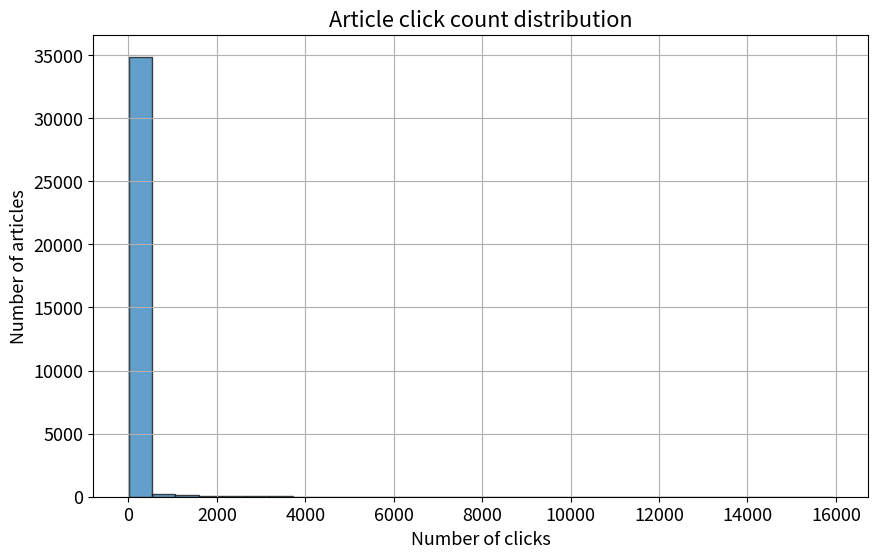

In [66]:
plt.figure(figsize=(10, 6))
plt.hist(item_click_count, bins=30, edgecolor='black', alpha=0.7)
plt.title('Article click count distribution')
plt.xlabel('Number of clicks')
plt.ylabel('Number of articles')
plt.grid(True)
plt.show()

In the data of article click counts, the following phenomena usually occur:

- A small number of articles will have very high click counts (such as popular articles).

- Most articles have few clicks, and may even have only 1~2 clicks (long tail effect).

In a regular histogram, articles with very high click counts may "compress" articles with low click counts.

The logarithmic distribution makes these data with large differences more comparable by performing a logarithmic transformation on the number of clicks.

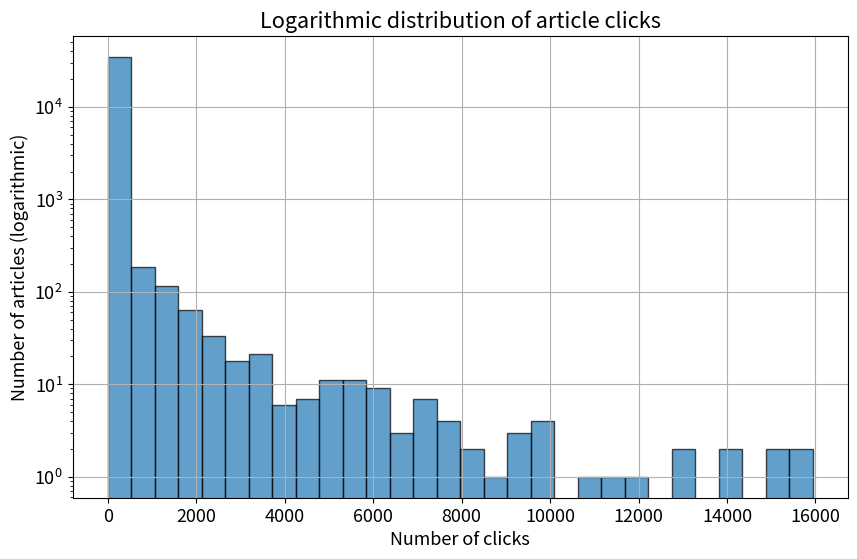

In [67]:
plt.figure(figsize=(10, 6))
plt.hist(item_click_count, bins=30, edgecolor='black', alpha=0.7, log=True)
plt.title('Logarithmic distribution of article clicks')
plt.xlabel('Number of clicks')
plt.ylabel('Number of articles (logarithmic)')
plt.grid(True)
plt.show()


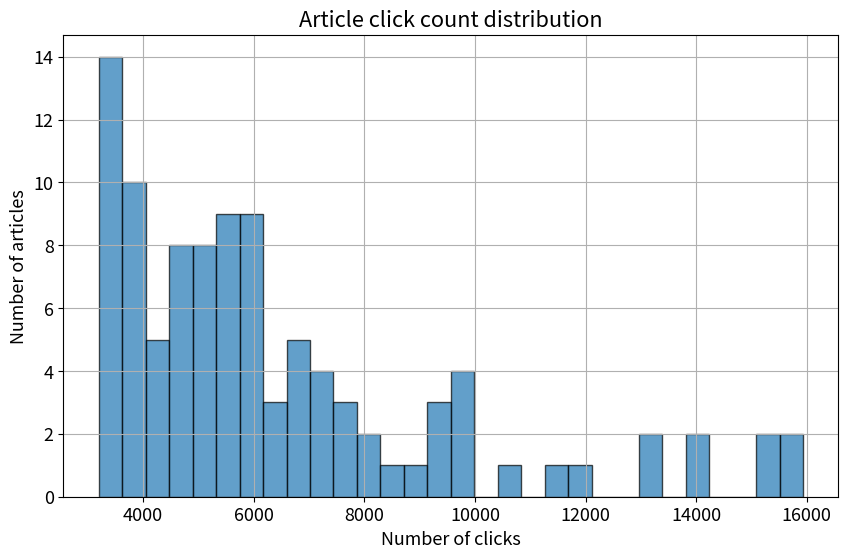

In [68]:
plt.figure(figsize=(10, 6))
plt.hist(item_click_count[:100], bins=30, edgecolor='black', alpha=0.7)
plt.title('Article click count distribution')
plt.xlabel('Number of clicks')
plt.ylabel('Number of articles')
plt.grid(True)
plt.show()

It can be seen that the top 100 news articles with the most clicks have more than 4,000 clicks.

In [69]:
# Get the top 10 articles with the highest number of clicks
top_10_articles = item_click_count[:10]
print("The top 10 articles with the highest number of clicks are:")
for i, count in enumerate(top_10_articles, 1):
  print(f"Number of clicks on the {i}th article: {count}")


The top 10 articles with the highest number of clicks are:
Number of clicks on the 1th article: 15935
Number of clicks on the 2th article: 15666
Number of clicks on the 3th article: 15383
Number of clicks on the 4th article: 15170
Number of clicks on the 5th article: 14009
Number of clicks on the 6th article: 13998
Number of clicks on the 7th article: 13277
Number of clicks on the 8th article: 13041
Number of clicks on the 9th article: 11968
Number of clicks on the 10th article: 11511


The top 20 news articles with the most clicks have more than 2500 clicks. Idea: These news articles can be defined as hot news. This is also a simple processing method. Later, we will also divide the popularity of articles according to the number of clicks and time.

Check for articles with very few clicks to see if there is a clear long-tail effect, where many articles have very few clicks.

In [70]:
# Count the number of articles with less than or equal to 2 clicks
low_click_count_articles = sum(clicks <= 2 for clicks in item_click_count)

print(f"The number of articles with less than or equal to 2 clicks is: {low_click_count_articles}")

The number of articles with less than or equal to 2 clicks is: 22408


It can be found that many news have only been clicked once or twice. Idea: These news can be defined as unpopular news

### News co-occurrence frequency: the number of times two news articles appear consecutively

News co-occurrence frequency is defined as the number of times a news article (click_article_id) and another news article (next_item) appear consecutively in a user's click behavior. This analysis can reveal users' reading habits and preferences.

If certain articles are often clicked together, it may mean that the two articles are related in topic, content or time.

In [71]:
tmp = user_click_merge.sort_values('click_timestamp')
tmp['next_item'] = tmp.groupby(['user_id'])['click_article_id'].transform(lambda x:x.shift(-1))
union_item = tmp.groupby(['click_article_id','next_item'])['click_timestamp'].agg({'count'}).reset_index().sort_values('count', ascending=False)
union_item[['count']].describe()

,count
count,433597.000000
mean,3.184139
std,18.851753
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,2202.000000


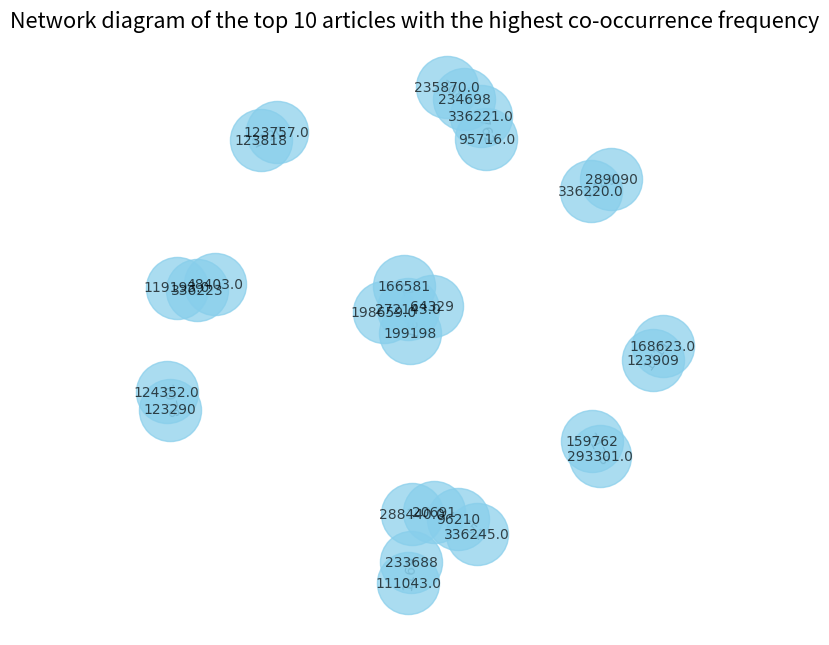

In [72]:
# Get the top 20 article pairs with the highest co-occurrence frequency
top_20_pairs = union_item.nlargest(20, 'count')
import networkx as nx
import matplotlib.pyplot as plt

# Create a graph
G = nx.from_pandas_edgelist(top_20_pairs, 'click_article_id', 'next_item', ['count'])

# Set drawing parameters
plt.figure(figsize=(6, 6))
pos = nx.spring_layout(G) # Select layout
nx.draw(G, pos, with_labels=True, node_size=2000, node_color='skyblue', font_size=10, font_color='black', edge_color='gray', alpha=0.7)

# Draw edge labels to show co-occurrence frequency
labels = nx.get_edge_attributes(G, 'count')
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

# Set title
plt.title('Network diagram of the top 10 articles with the highest co-occurrence frequency')
plt.show()



In [73]:
pair_detail = item_df[item_df['click_article_id'].isin(set(top_20_pairs['click_article_id'].astype(float).astype(int)) | set(top_20_pairs['next_item'].astype(float).astype(int)))]
pair_detail

,click_article_id,category_id,created_at_ts,words_count
20691,20691,9,1507826236000,226
48403,48403,92,1507563541000,265
64329,64329,134,1506970055000,199
95716,95716,209,1507584182000,222
96210,96210,209,1507798791000,274
111043,111043,231,1507732818000,195
119193,119193,247,1507565823000,296
123290,123290,250,1507224971000,201
123757,123757,250,1507223128000,194
123818,123818,250,1507220064000,220


### News article information

In [74]:
#The number of times different types of news appear
user_click_merge['category_id'].value_counts()

,count
category_id,
281,179455
375,152587
250,94229
412,92587
437,90056
...,...
116,1
229,1
318,1


### User's preference for the type of news they click on

This feature can be used to measure whether the user's interests are broad.

In [75]:
user_interest_count = user_click_merge.groupby('user_id')['category_id'].nunique()
user_interest_count

,category_id
user_id,
0,2
1,2
2,2
3,2
4,2
...,...
249995,18
249996,1
249997,4


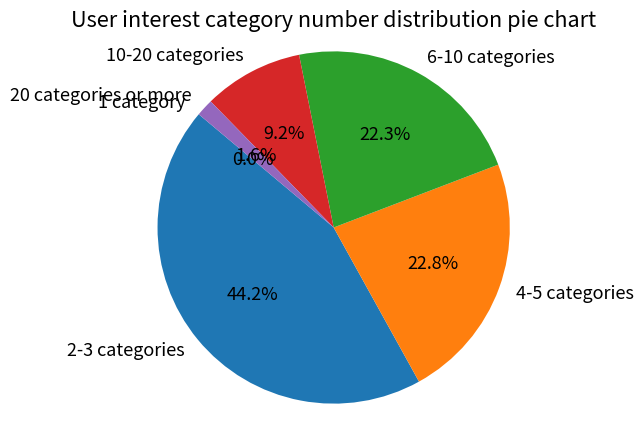

In [76]:
interest_bins = [0, 1, 3, 5, 10, 20, float('inf')]
labels = ['1 category', '2-3 categories', '4-5 categories', '6-10 categories', '10-20 categories', '20 categories or more']
interest_categories = pd.cut(user_interest_count, bins=interest_bins, labels=labels, right=False)

plt.figure(figsize=(5, 5))
interest_distribution = interest_categories.value_counts()
plt.pie(interest_distribution, labels=interest_distribution.index, autopct='%1.1f%%', startangle=140)
plt.title('User interest category number distribution pie chart')
plt.axis('equal') # Keep the pie chart round
plt.show()


From the above figure, we can see that a small number of users read a wide range of news types, while most people read less than 20 news types.

### Analysis of the time when users click on news

In [77]:
# About six minutes
def mean_diff_time_func(df, col):
  # Convert timestamp to datetime format
  df[col] = pd.to_datetime(df[col], unit='ms') # Assume timestamp is in milliseconds

  # Calculate the previous time point
  df['time_shift1'] = df[col].shift(1)

  # Calculate the time difference and convert to minutes
  df['diff_time'] = (df[col] - df['time_shift1']).dt.total_seconds() / 60

  return df['diff_time'].mean()


# First sort the data by user and click timestamp
user_click_merge_sorted = user_click_merge.sort_values(by=['user_id', 'click_timestamp'])

# Then filter out users with more than 2 clicks
filtered_users = user_click_merge_sorted.groupby('user_id').filter(lambda x: len(x) > 2)


mean_diff_click_time = filtered_users.groupby('user_id').apply(lambda x: mean_diff_time_func(x, 'click_timestamp'))

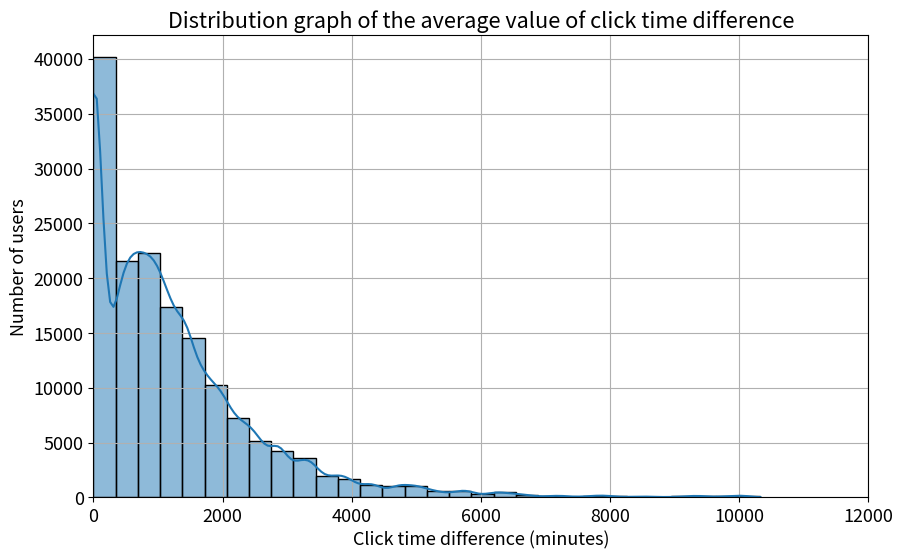

In [78]:
mean_diff_click_time_df = mean_diff_click_time.reset_index()

# Draw a distribution graph
plt.figure(figsize=(10, 6))
sns.histplot(mean_diff_click_time_df[0], bins=30, kde=True) # Use kde=True to overlay the kernel density estimation curve
plt.title('Distribution graph of the average value of click time difference')
plt.xlabel('Click time difference (minutes)')
plt.xlim(0,12000)
plt.ylabel('Number of users')
plt.grid()
plt.show()

From the above figure, we can see that the time difference between different users clicking on the article is different

## Summary

Through the process of data analysis, we can currently obtain the following important information, which is very helpful for our subsequent feature creation and analysis:

1. The user IDs of the training set and the test set are not repeated, that is, the user model in the test set has never seen

2. The minimum number of articles clicked by users in the training set is 2, while the minimum number of articles clicked by users in the test set is 1

3. Users have repeated clicks on articles, but this exists in the training set

4. The click environment of the same user is not unique. When making this part of the features later, statistical features can be used

5. The number of times users click on articles has a large degree of differentiation, and features for measuring user activity can be made based on this later

6. The number of times an article is clicked by users also has a large degree of differentiation, and features for measuring article popularity can be made based on this later

7. The news that users read is highly relevant, so when we often judge whether a user is interested in a certain article, it is often related to the articles he has clicked in the past to a large extent

8. The number of words in the articles clicked by users is quite different, which can reflect the difference in the number of words in the articles

9. The topics of the articles clicked by users are also very different, This can reflect the user's topic preference
10. The time difference between different users clicking on articles will also be different, which can reflect the user's preference for the timeliness of articles

So based on the above analysis, it can better help us do feature engineering later and fully explore the implicit information of the data.

## Insights

1. **User uniqueness:** The user IDs of the training set and the test set are not repeated, and the user model in the test set has never been seen. This indicates that the model will encounter new users in the test phase, and the cold start problem needs to be considered, such as how to make recommendations for new users.
2. **User behavior characteristics:**
  - In the training set, the minimum number of articles clicked by users is 2, while the minimum number of articles clicked by users in the test set is 1. This shows that there may be more sparse user behaviors in the test set, and attention should be paid to the robustness of the model.
  - Users have repeated clicks on articles, which is an important user behavior feature. You can consider counting the number of clicks of users on the same article as a feature.
3. **Diversity of click environment:** The click environment of the same user is not unique. When making features, you can consider introducing statistical features related to the click environment, such as the variance of click time, the diversity of click devices, etc.
4. **Click count feature:**
  - The number of times a user clicks on an article has a large degree of differentiation, which can be used to measure the activity of the user. Features related to the number of user clicks can be constructed, such as the average number of clicks, the distribution of clicks, etc.
  - The number of times an article is clicked by a user also has a great degree of differentiation, which can be used to measure the popularity of an article. Features related to the number of clicks on an article can be constructed, such as the average number of clicks, the distribution of clicks, etc.
5. **User historical behavior correlation:** The news that a user reads is highly correlated with the articles that he has clicked on in the past. You can consider constructing features related to the correlation of historical clicks on articles by users, such as articles with similar themes to the articles that the user has recently clicked on.
6. **Article attribute features:**
  - The number of words in the articles that users have clicked on varies greatly, which can be used to reflect the user's preference for the number of words in the article. Features related to the number of words in the article can be constructed, such as the average number of words in the article, the distribution of the number of words, etc.
  - The topics of the articles that users have clicked on vary greatly, which can be used to reflect the user's topic preference. Features related to the topic of the article can be constructed, such as the distribution of topics that users have clicked on.
7. **Time features:** The time difference between different users clicking on articles varies, reflecting the user's preference for the timeliness of the article. Features related to the time difference between users clicking on articles can be constructed, such as the average time difference, the distribution of the time difference, etc.